# Spotify & YouTube Music Data Analysis

Ez a notebook egy **Spotify + YouTube zenei adathalmaz** feltáró elemzését (EDA) mutatja be. A projekt célja, hogy bemutassa az adattisztítás, hiányzóadat-kezelés, aggregálás, korrelációelemzés és vizualizáció alapvető lépéseit `pandas`, `NumPy`, `matplotlib` és `seaborn` segítségével.

**Felhasznált eszközök:** Python, pandas, NumPy, matplotlib, seaborn

**Az adathalmaz:** 20 718 szám adatai (Spotify audio feature-ök: danceability, energy, loudness stb.) összekapcsolva a hozzájuk tartozó YouTube videó statisztikákkal (megtekintés, like, komment, stream szám).

## Tartalom
1. Adatbetöltés és első áttekintés
2. Hiányzó adatok feltárása és kezelése
3. Típuskonverziók és tisztítás
4. Alap aggregációk (top előadók, top dalok)
5. Vizualizációk és korrelációelemzés
6. **Új elemzések:** hangulat (valence) vizsgálat, official vs. nem-official videók, licenszelt tartalom aránya, leghangosabb/legenergikusabb dalok, hangnem szerinti eloszlás


## 1. Adatbetöltés és könyvtárak importálása

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('spotify_yt.csv')
df.head()

,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,215150.0,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


## 2. Első áttekintés

Megnézzük az adathalmaz alapstatisztikáit (`describe`) és szerkezetét (`info`), hogy lássuk az oszlopok típusát és a hiányzó értékek nagyságrendjét.

In [3]:
print(df.describe())
df.info()

       Danceability        Energy           Key      Loudness   Speechiness  \
count  20708.000000  20609.000000  20716.000000  20447.000000  20716.000000   
mean       0.619764      0.635299      5.300348     -7.673321      0.096456   
std        0.165275      0.214133      3.576449      4.635906      0.111960   
min        0.000000      0.000020      0.000000    -46.251000      0.000000   
25%        0.518750      0.507000      2.000000     -8.860500      0.035700   
50%        0.637000      0.666000      5.000000     -6.536000      0.050500   
75%        0.740000      0.798000      8.000000     -4.930500      0.103000   
max        0.975000      1.000000     11.000000      0.920000      0.964000   

       Acousticness  Instrumentalness      Liveness       Valence  \
count  20633.000000      20664.000000  20716.000000  20716.000000   
mean       0.291424          0.056031      0.193521      0.529853   
std        0.286274          0.193375      0.168531      0.245441   
min        0

### 2.1 Hiányzó adatok feltárása

Minden oszlopra megnézzük, hány hiányzó (`NaN`) érték található.

In [4]:
print(df.isnull().sum())

Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability         10
Energy              109
Key                   2
Loudness            271
Speechiness           2
Acousticness         85
Instrumentalness     54
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Url_youtube         470
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description         876
Licensed            470
official_video      470
Stream              576
dtype: int64


## 3. Hiányzó adatok kezelése

A hangulati/audio jellemzők (`Loudness`, `Acousticness`, `Instrumentalness`, `Energy`, `Danceability`) hiányzó értékeit **előadó szerinti csoportos átlaggal** töltjük fel, mert egy előadó számai jellemzően hasonló stílusúak, így ez pontosabb becslés, mint a globális átlag.

In [5]:
missing_column = ['Loudness', 'Acousticness', 'Instrumentalness', 'Energy', 'Danceability']

for col in missing_column:
    df[col] = df[col].fillna(df.groupby('Artist')[col].transform('mean'))

print(df[missing_column].isnull().sum())

Loudness            0
Acousticness        0
Instrumentalness    0
Energy              0
Danceability        0
dtype: int64


Azokat a sorokat, ahol a legfontosabb audio jellemzők (`check_cols`) továbbra is hiányoznak (mert az előadónak sincs elérhető átlaga), eldobjuk.

In [6]:
check_cols = ['Speechiness', 'Liveness', 'Valence', 'Tempo', 'Key', 'Duration_ms']

print(df[df[check_cols].isnull().any(axis=1)])
df.dropna(subset=check_cols, inplace=True)
print(df[df[check_cols].isnull().any(axis=1)])

                       Artist  \
11890     Natasha Bedingfield   
13843  White Noise for Babies   

                                             Url_spotify  \
11890  https://open.spotify.com/artist/7o95ZoZt5ZYn31...   
13843  https://open.spotify.com/artist/4ZfEELHfyKd4od...   

                           Track  \
11890                These Words   
13843  Rain in the Early Morning   

                                                   Album Album_type  \
11890                                          Unwritten      album   
13843  Soothing Rain for Background Sounds and Natura...      album   

                                        Uri  Danceability    Energy  Key  \
11890  spotify:track:6MFQeWtk7kxWGydnJB2y36      0.593222  0.663778  NaN   
13843  spotify:track:4juc1w1fGFn8CxKp8gGThc      0.080233  0.077183  NaN   

        Loudness  Speechiness  Acousticness  Instrumentalness  Liveness  \
11890  -6.277444          NaN      0.208133          0.000694       NaN   
13843 -31.195778 

## 4. Típuskonverziók

A numerikus oszlopokat egész számmá, a logikai oszlopokat pedig valódi boolean típussá alakítjuk, hogy az elemzés és a memóriahasználat is hatékonyabb legyen.

In [7]:
print(df.dtypes)

int_cols = ['Duration_ms', 'Key', 'Views', 'Likes', 'Comments', 'Stream']
for col in int_cols:
    df[col] = df[col].fillna(-1).astype(int)

bool_cols = ['Licensed', 'official_video']
for col in bool_cols:
    df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)

Artist               object
Url_spotify          object
Track                object
Album                object
Album_type           object
Uri                  object
Danceability        float64
Energy              float64
Key                 float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Duration_ms         float64
Url_youtube          object
Title                object
Channel              object
Views               float64
Likes               float64
Comments            float64
Description          object
Licensed             object
official_video       object
Stream              float64
dtype: object


/tmp/ipykernel_827/3273388776.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)
/tmp/ipykernel_827/3273388776.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).infer_objects(copy=False).astype(bool)


Eldobjuk a stream nélküli sorokat (`Stream == -1`, azaz eredetileg hiányzó érték volt), valamint a nem szükséges URL/URI oszlopokat, hogy tisztább legyen az adathalmaz.

In [8]:
df = df[df['Stream'] != -1]
df = df.drop(['Url_spotify', 'Uri'], axis=1)

df.to_csv('spotify_yt_cleaned.csv', index=False)
print(f"Végleges sorok száma: {len(df)}")

Végleges sorok száma: 20140


In [9]:
print(df['Url_youtube'].notnull().sum())

19691


## 5. Alap aggregációk

### 5.1 Legjobb "tánckészség" (danceability) szerinti előadók

In [10]:
top_dance_artist = (
    df.groupby('Artist')['Danceability'].mean().sort_values(ascending=False).head(10)
)
print(top_dance_artist)

Artist
Saweetie                  0.885800
Three 6 Mafia             0.866556
Young Dolph               0.862900
Megan Thee Stallion       0.860500
Dave                      0.859100
Plan B                    0.858286
Ovy On The Drums          0.854600
Ski Mask The Slump God    0.852800
Migos                     0.851100
Blueface                  0.850200
Name: Danceability, dtype: float64


### 5.2 Legtöbbet streamelt és nézett előadók

Oszlopdiagrammal hasonlítjuk össze a top 10 előadó Spotify stream és YouTube megtekintés számát, két y tengellyel.

                      Stream        Views
Artist                                   
Post Malone      15251263853   6394420209
Ed Sheeran       14394881557  15460207769
Dua Lipa         13408076274   8216339307
XXXTENTACION     13224351699   2546374320
The Weeknd       13031973376   7046033154
Justin Bieber    12097767422  10991060236
Imagine Dragons  11858310928   9093785238
Coldplay         11778478236   9997277884
Khalid           11386839915   5398246275
Bruno Mars       10897862950  10240919227


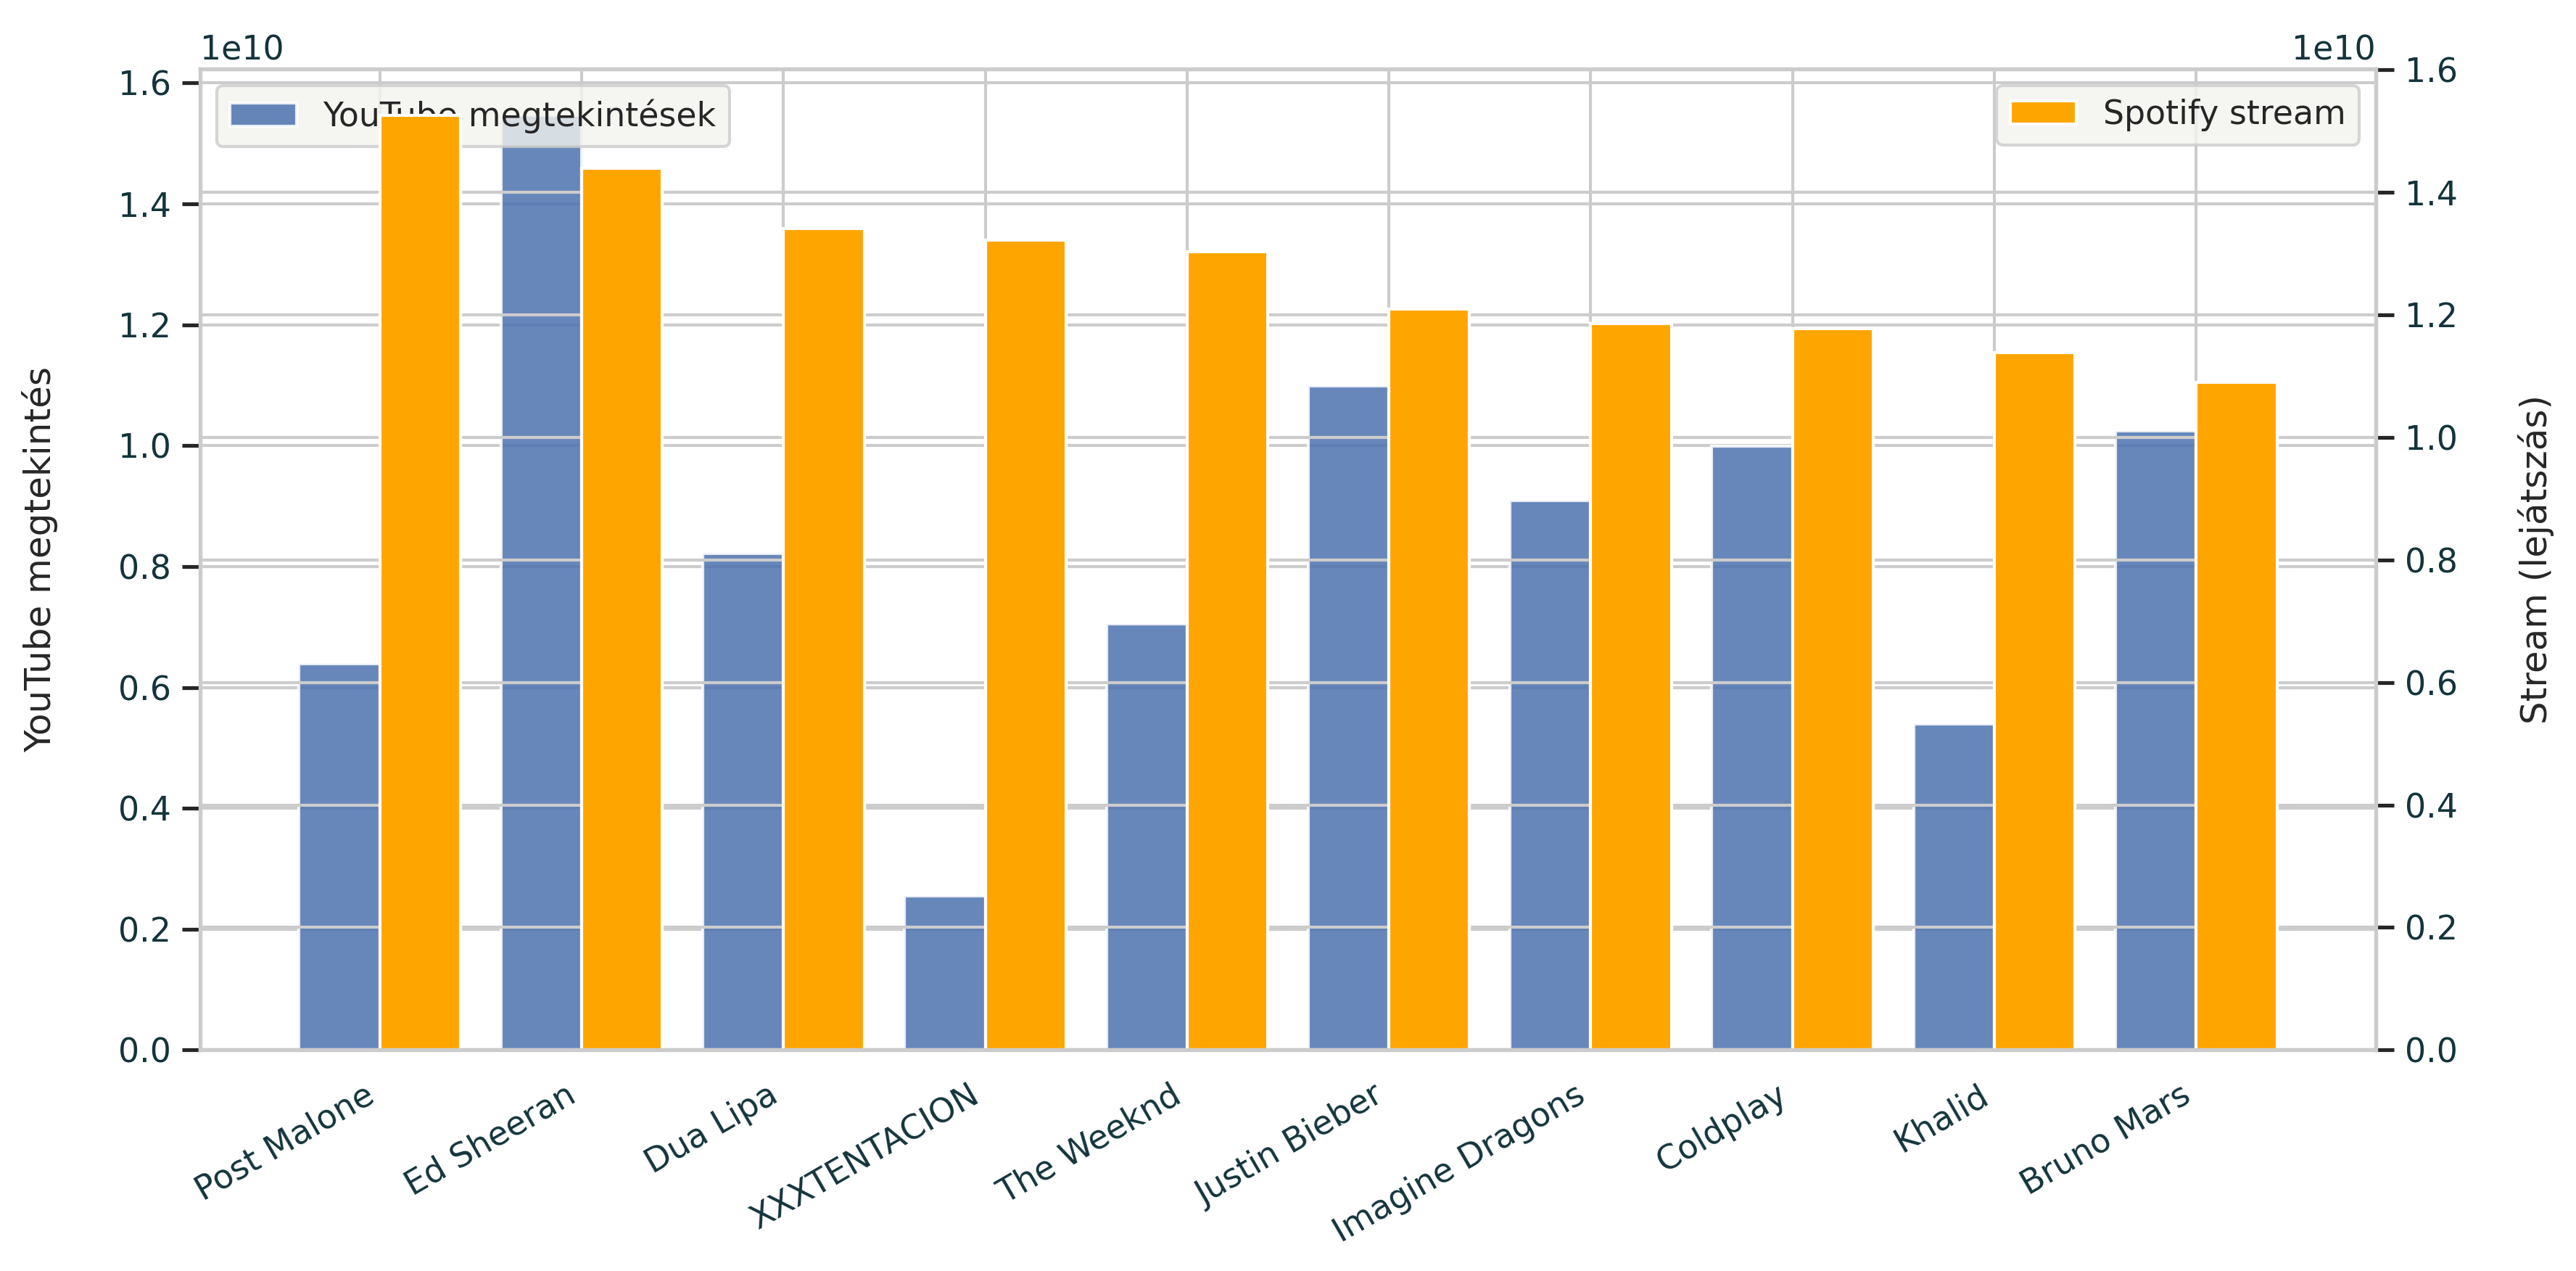

In [11]:
artist_stats = (
    df.groupby('Artist')[['Stream', 'Views']].sum().sort_values(by='Stream', ascending=False).head(10)
)
print(artist_stats)

artists = artist_stats.index
streams = artist_stats['Stream']
views = artist_stats['Views']

x = range(len(artists))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar([i - width/2 for i in x], views, label='YouTube megtekintések', alpha=0.85, width=width)
ax1.set_ylabel('YouTube megtekintés')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], streams, label='Spotify stream', width=width, color='orange')
ax2.set_ylabel('Stream (lejátszás)')
ax2.tick_params(axis='y')

ax1.set_xticks(list(x))
ax1.set_xticklabels(artists, rotation=30, ha='right')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Top 10 legtöbbet streamelt előadó - Stream vs YouTube megtekintés')
fig.tight_layout()
plt.show()

## 6. Korrelációelemzés

A top 10 legnépszerűbb dal audio jellemzői közötti korrelációt vizualizáljuk hőtérképpel.

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...lációja', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...lációja', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...lációja', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...lációja', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK.

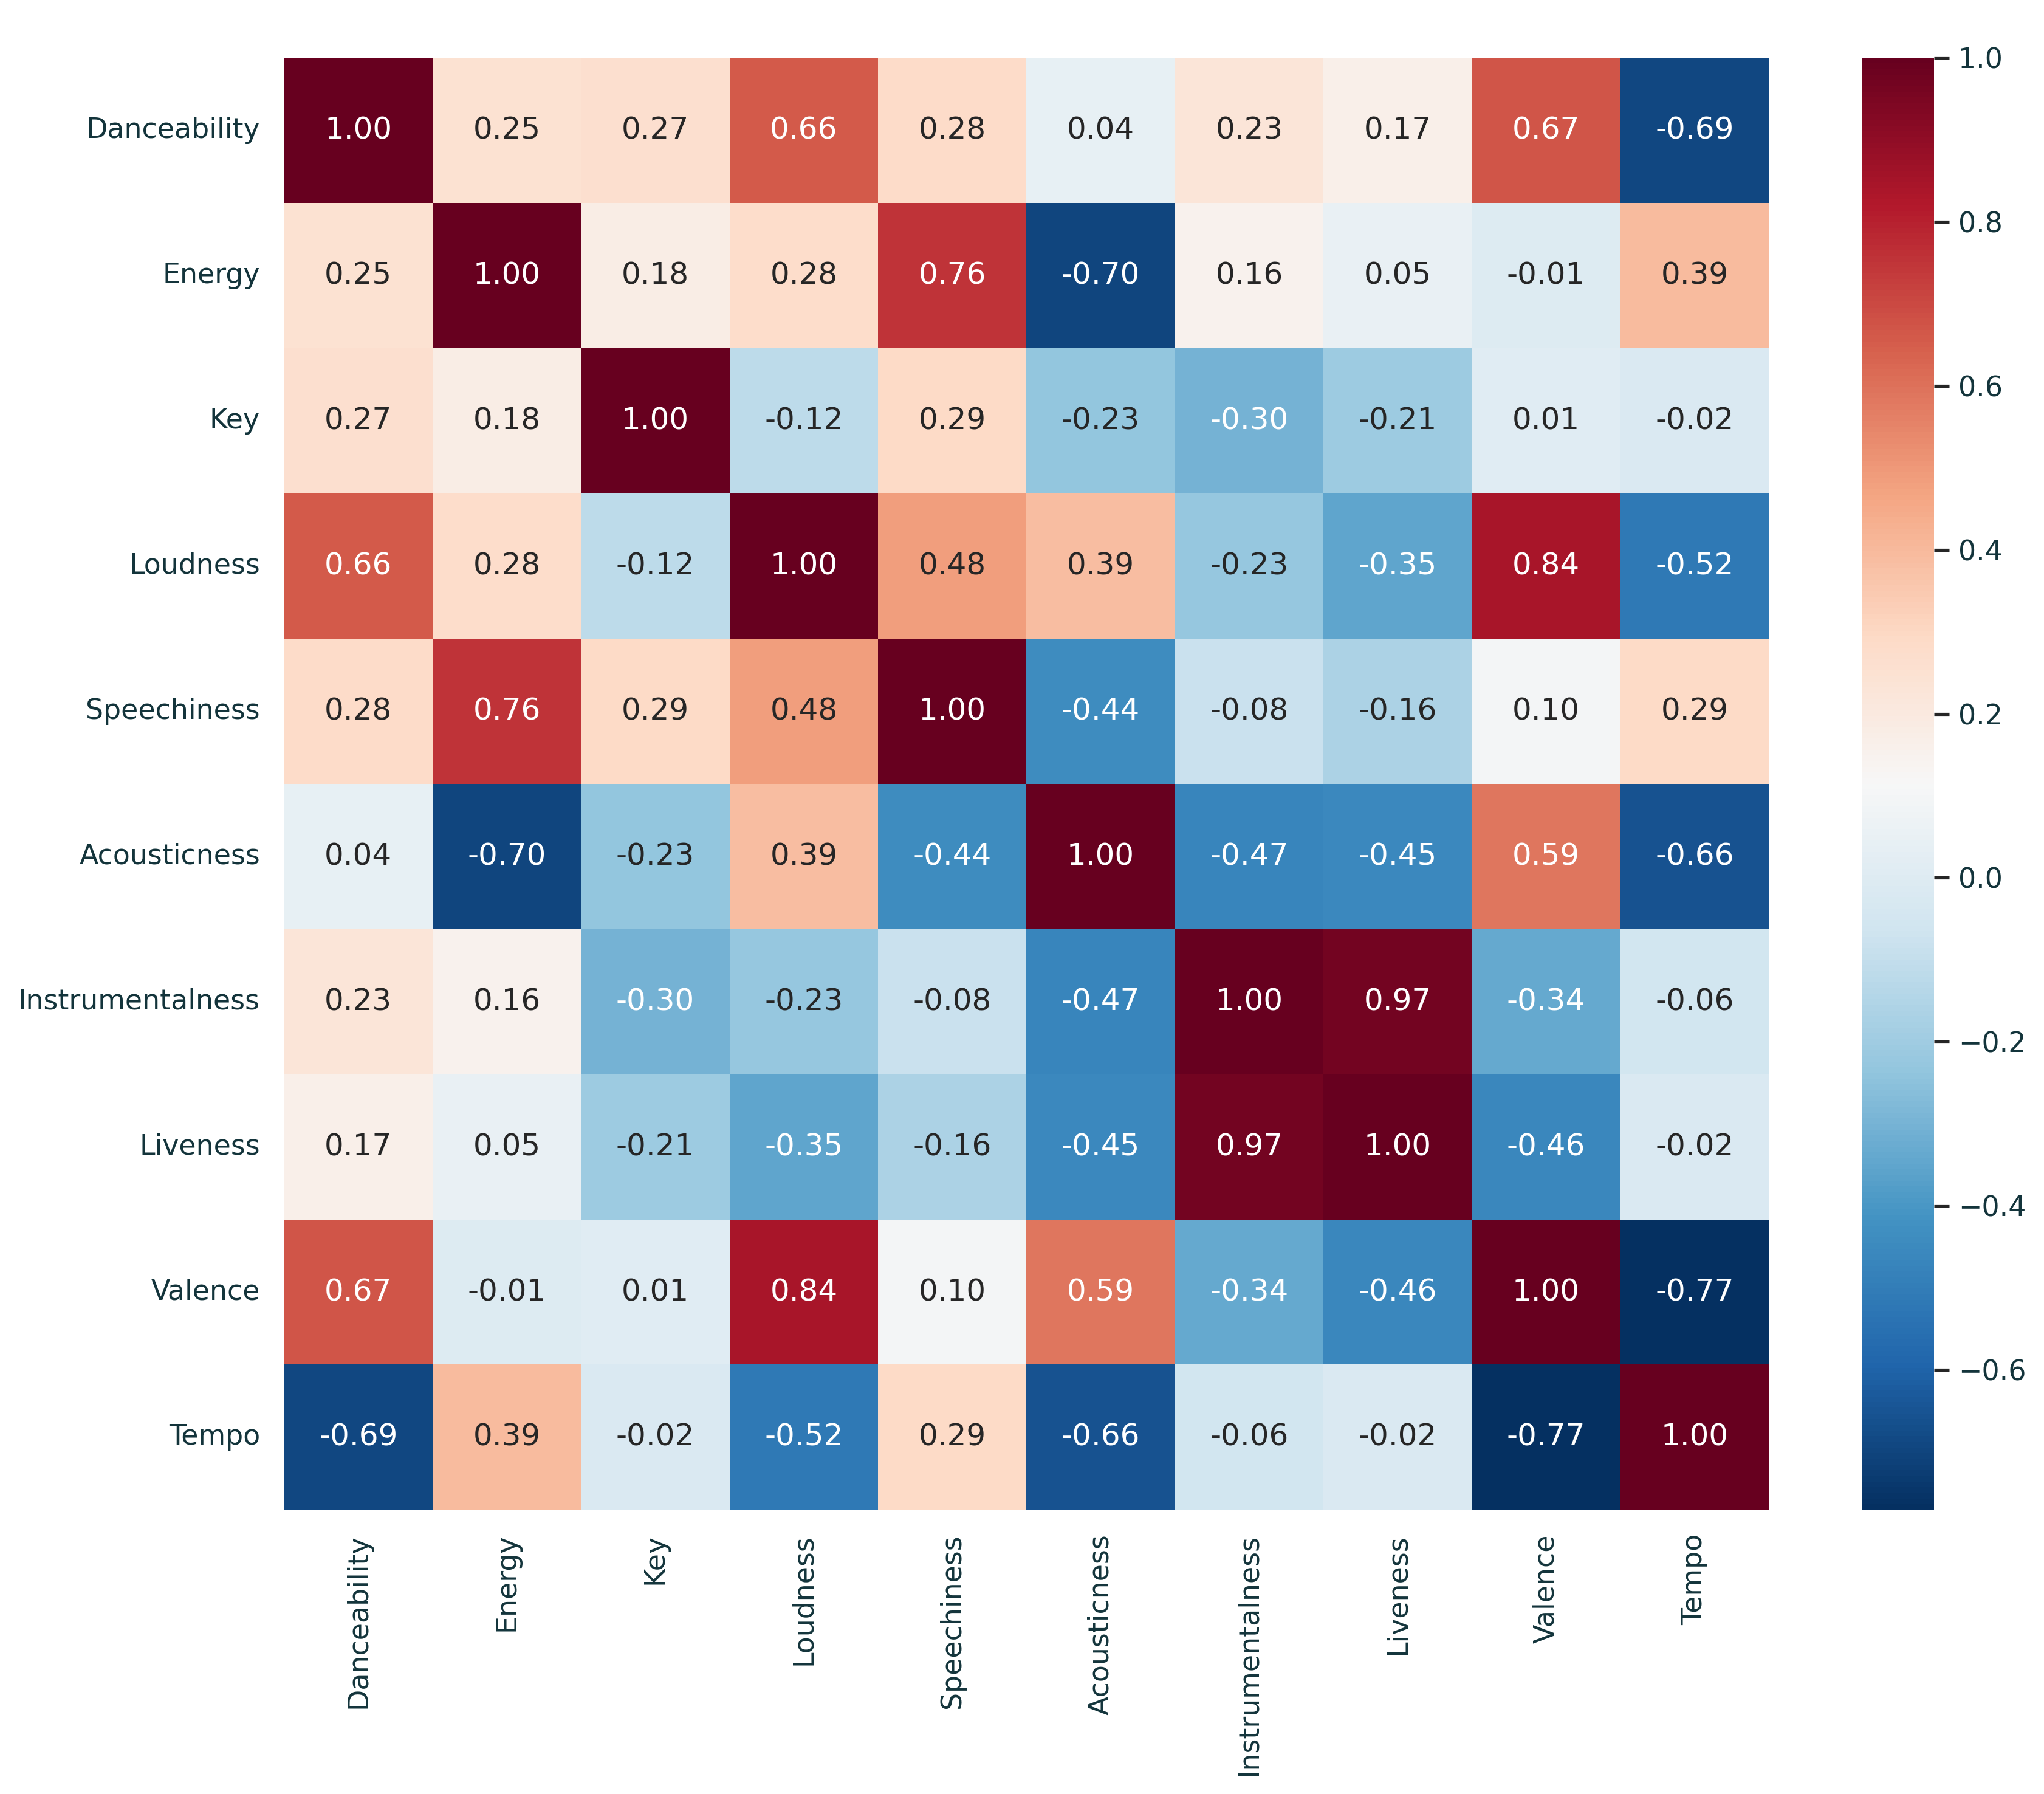

In [12]:
top10_songs = df.sort_values('Stream', ascending=False).head(10)

music_features = [
    'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo'
]

correlation_matrix = top10_songs[music_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Top 10 legnépszerűbb dal tulajdonságainak korrelációja')
plt.tight_layout()
plt.show()

## 7. Kiválasztott előadók összehasonlítása

Konkrét előadók (`Drake`, `J. Cole`, `Kendrick Lamar`) stream és megtekintés adatait hasonlítjuk össze.

In [13]:
artists_of_interest = ['J. Cole', 'Kendrick Lamar', 'Drake']
mask = df['Artist'].isin(artists_of_interest)

comparison = df[mask].groupby('Artist')[['Stream', 'Views']].sum()
print(comparison)

                    Stream       Views
Artist                                
Drake           6662057819  1822165166
J. Cole         6162421576   915778736
Kendrick Lamar  7113441426  1993348461


## 8. Új elemzés: hangulat (Valence) alakulása albumtípus szerint

A `Valence` (0-1 közötti érték) azt méri, mennyire "pozitív hangulatú" egy dal. Megnézzük, hogy az album-, single- vagy compilation-megjelenésű számok átlagos hangulata eltér-e egymástól.

                 mean  median  count
Album_type                          
single       0.529810   0.534   4850
album        0.529512   0.538  14556
compilation  0.527775   0.536    734


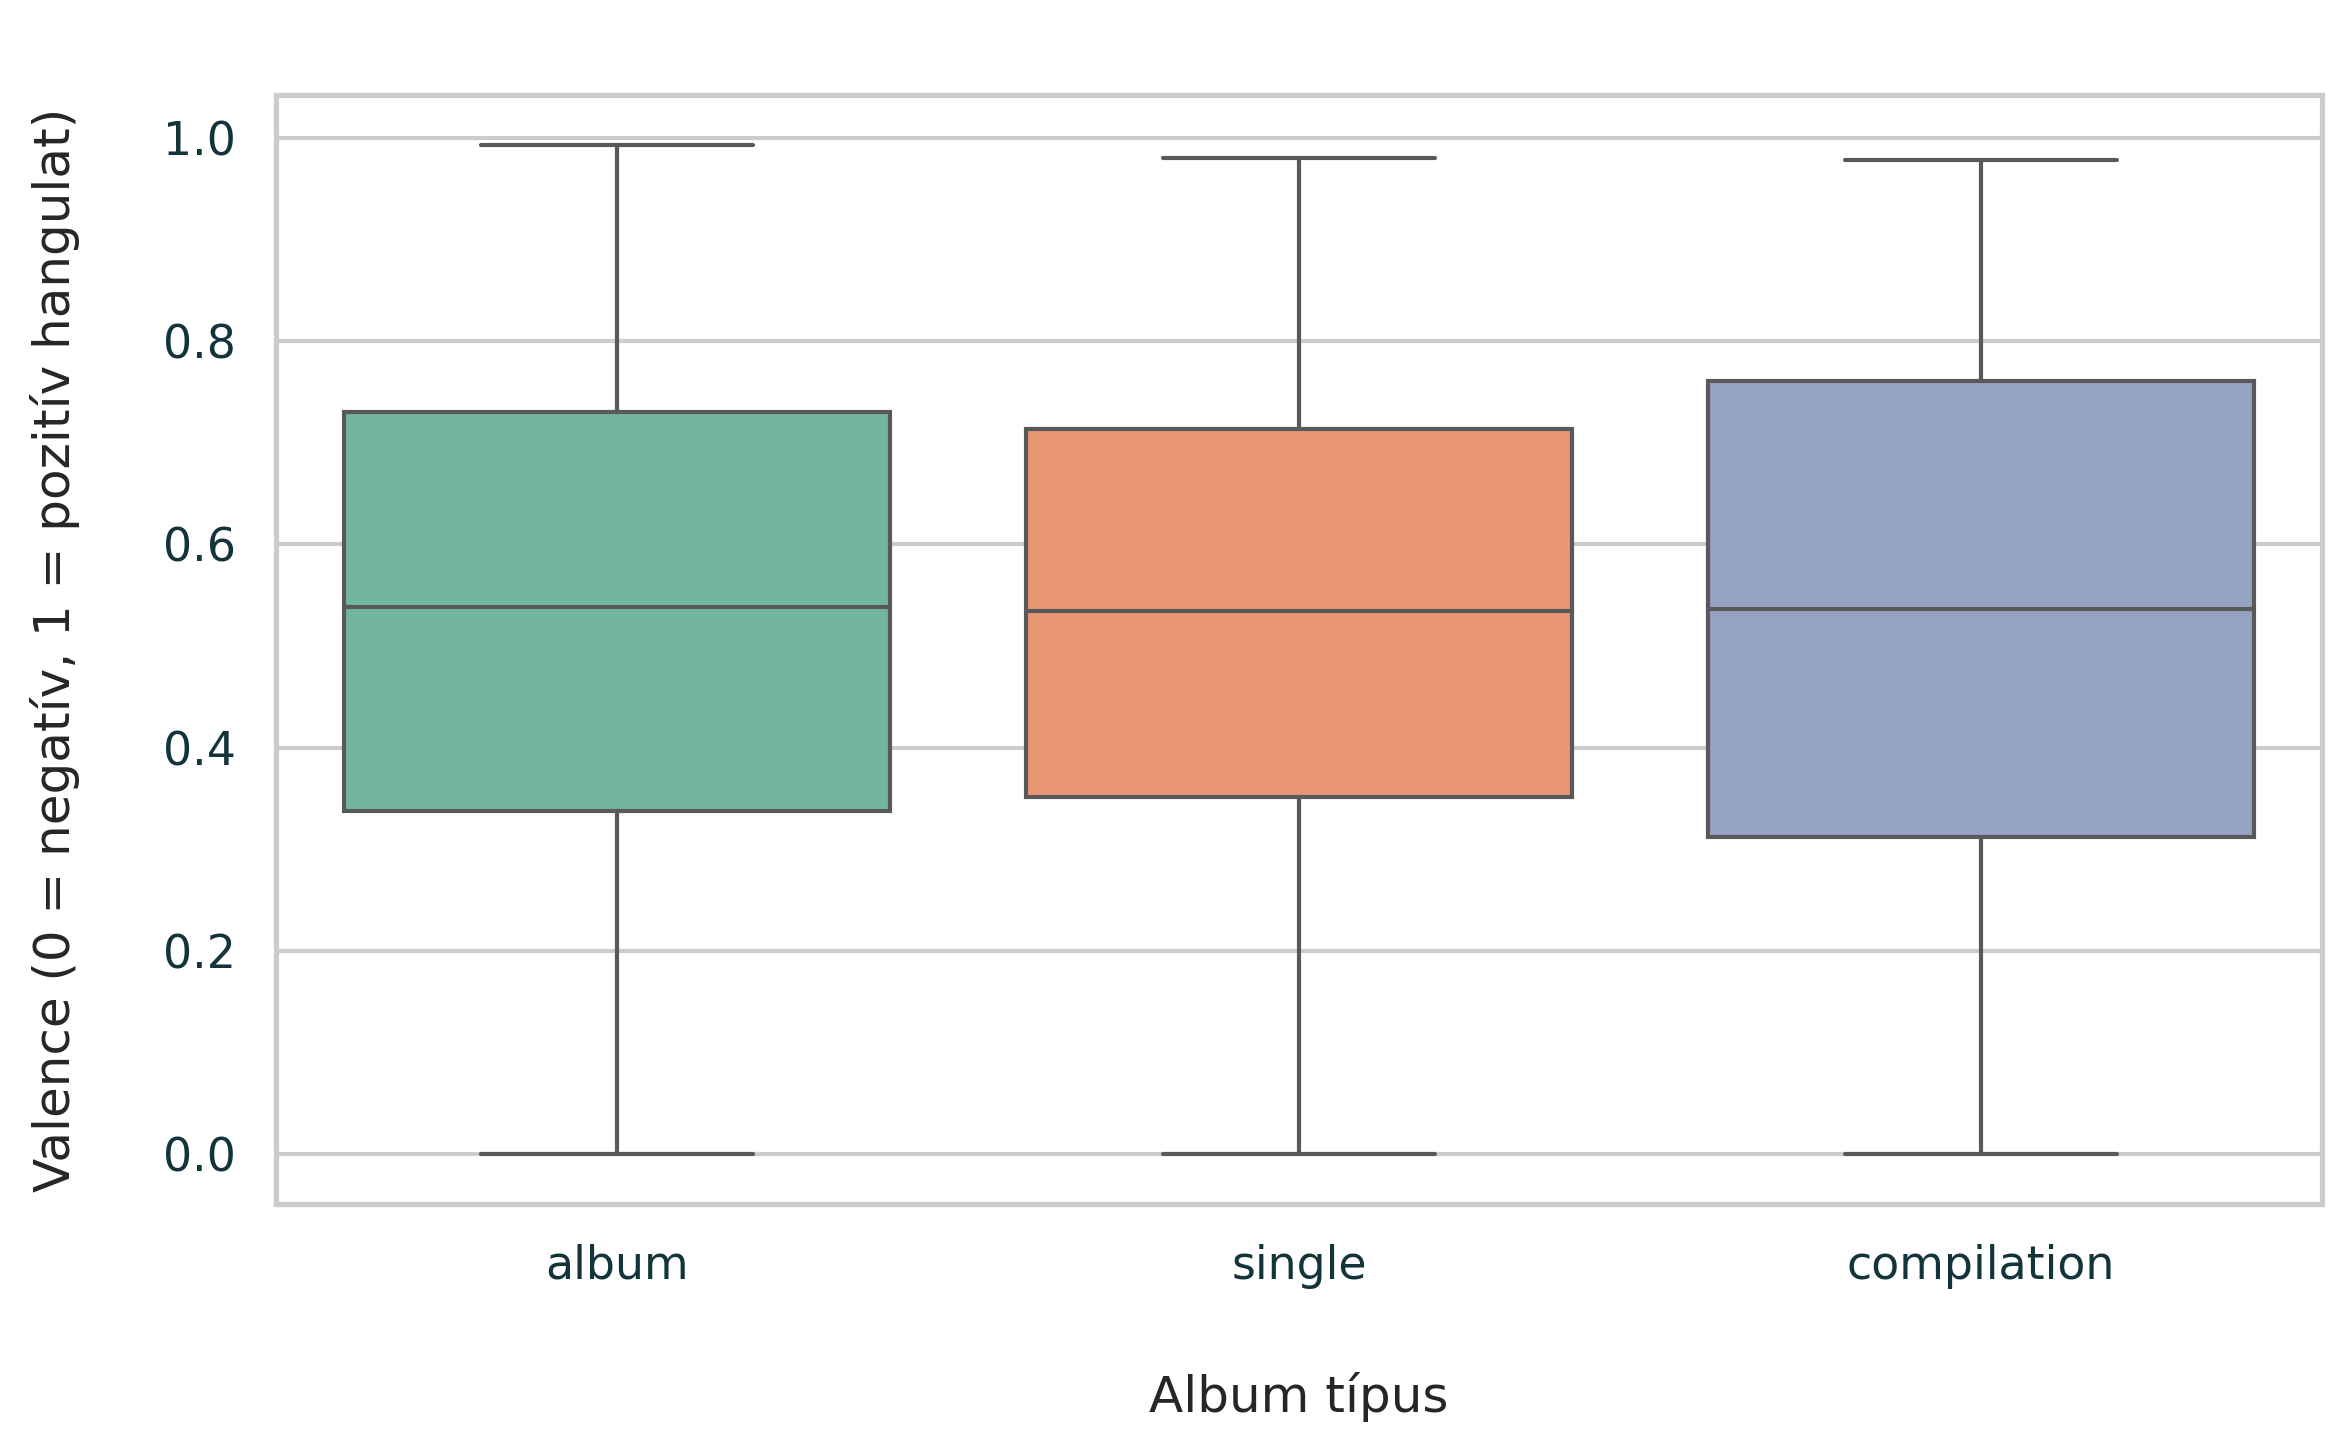

In [14]:
valence_by_albumtype = (
    df.groupby('Album_type')['Valence']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)
print(valence_by_albumtype)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Album_type', y='Valence', hue='Album_type', palette='Set2', legend=False)
plt.title('Hangulat (Valence) eloszlása album típusonként')
plt.xlabel('Album típus')
plt.ylabel('Valence (0 = negatív, 1 = pozitív hangulat)')
plt.tight_layout()
plt.show()

## 9. Új elemzés: Official Video vs. nem hivatalos videó teljesítménye

Megvizsgáljuk, hogy a hivatalos videóklippel rendelkező számok átlagosan több megtekintést/lájkot kapnak-e, mint a nem hivatalos feltöltések.

                            Views          Likes      Comments        Stream
official_video                                                              
Nem hivatalos videó  1.983618e+07  155880.667151   6645.244546  8.931269e+07
Hivatalos videó      1.158799e+08  808365.509624  33485.641287  1.505859e+08


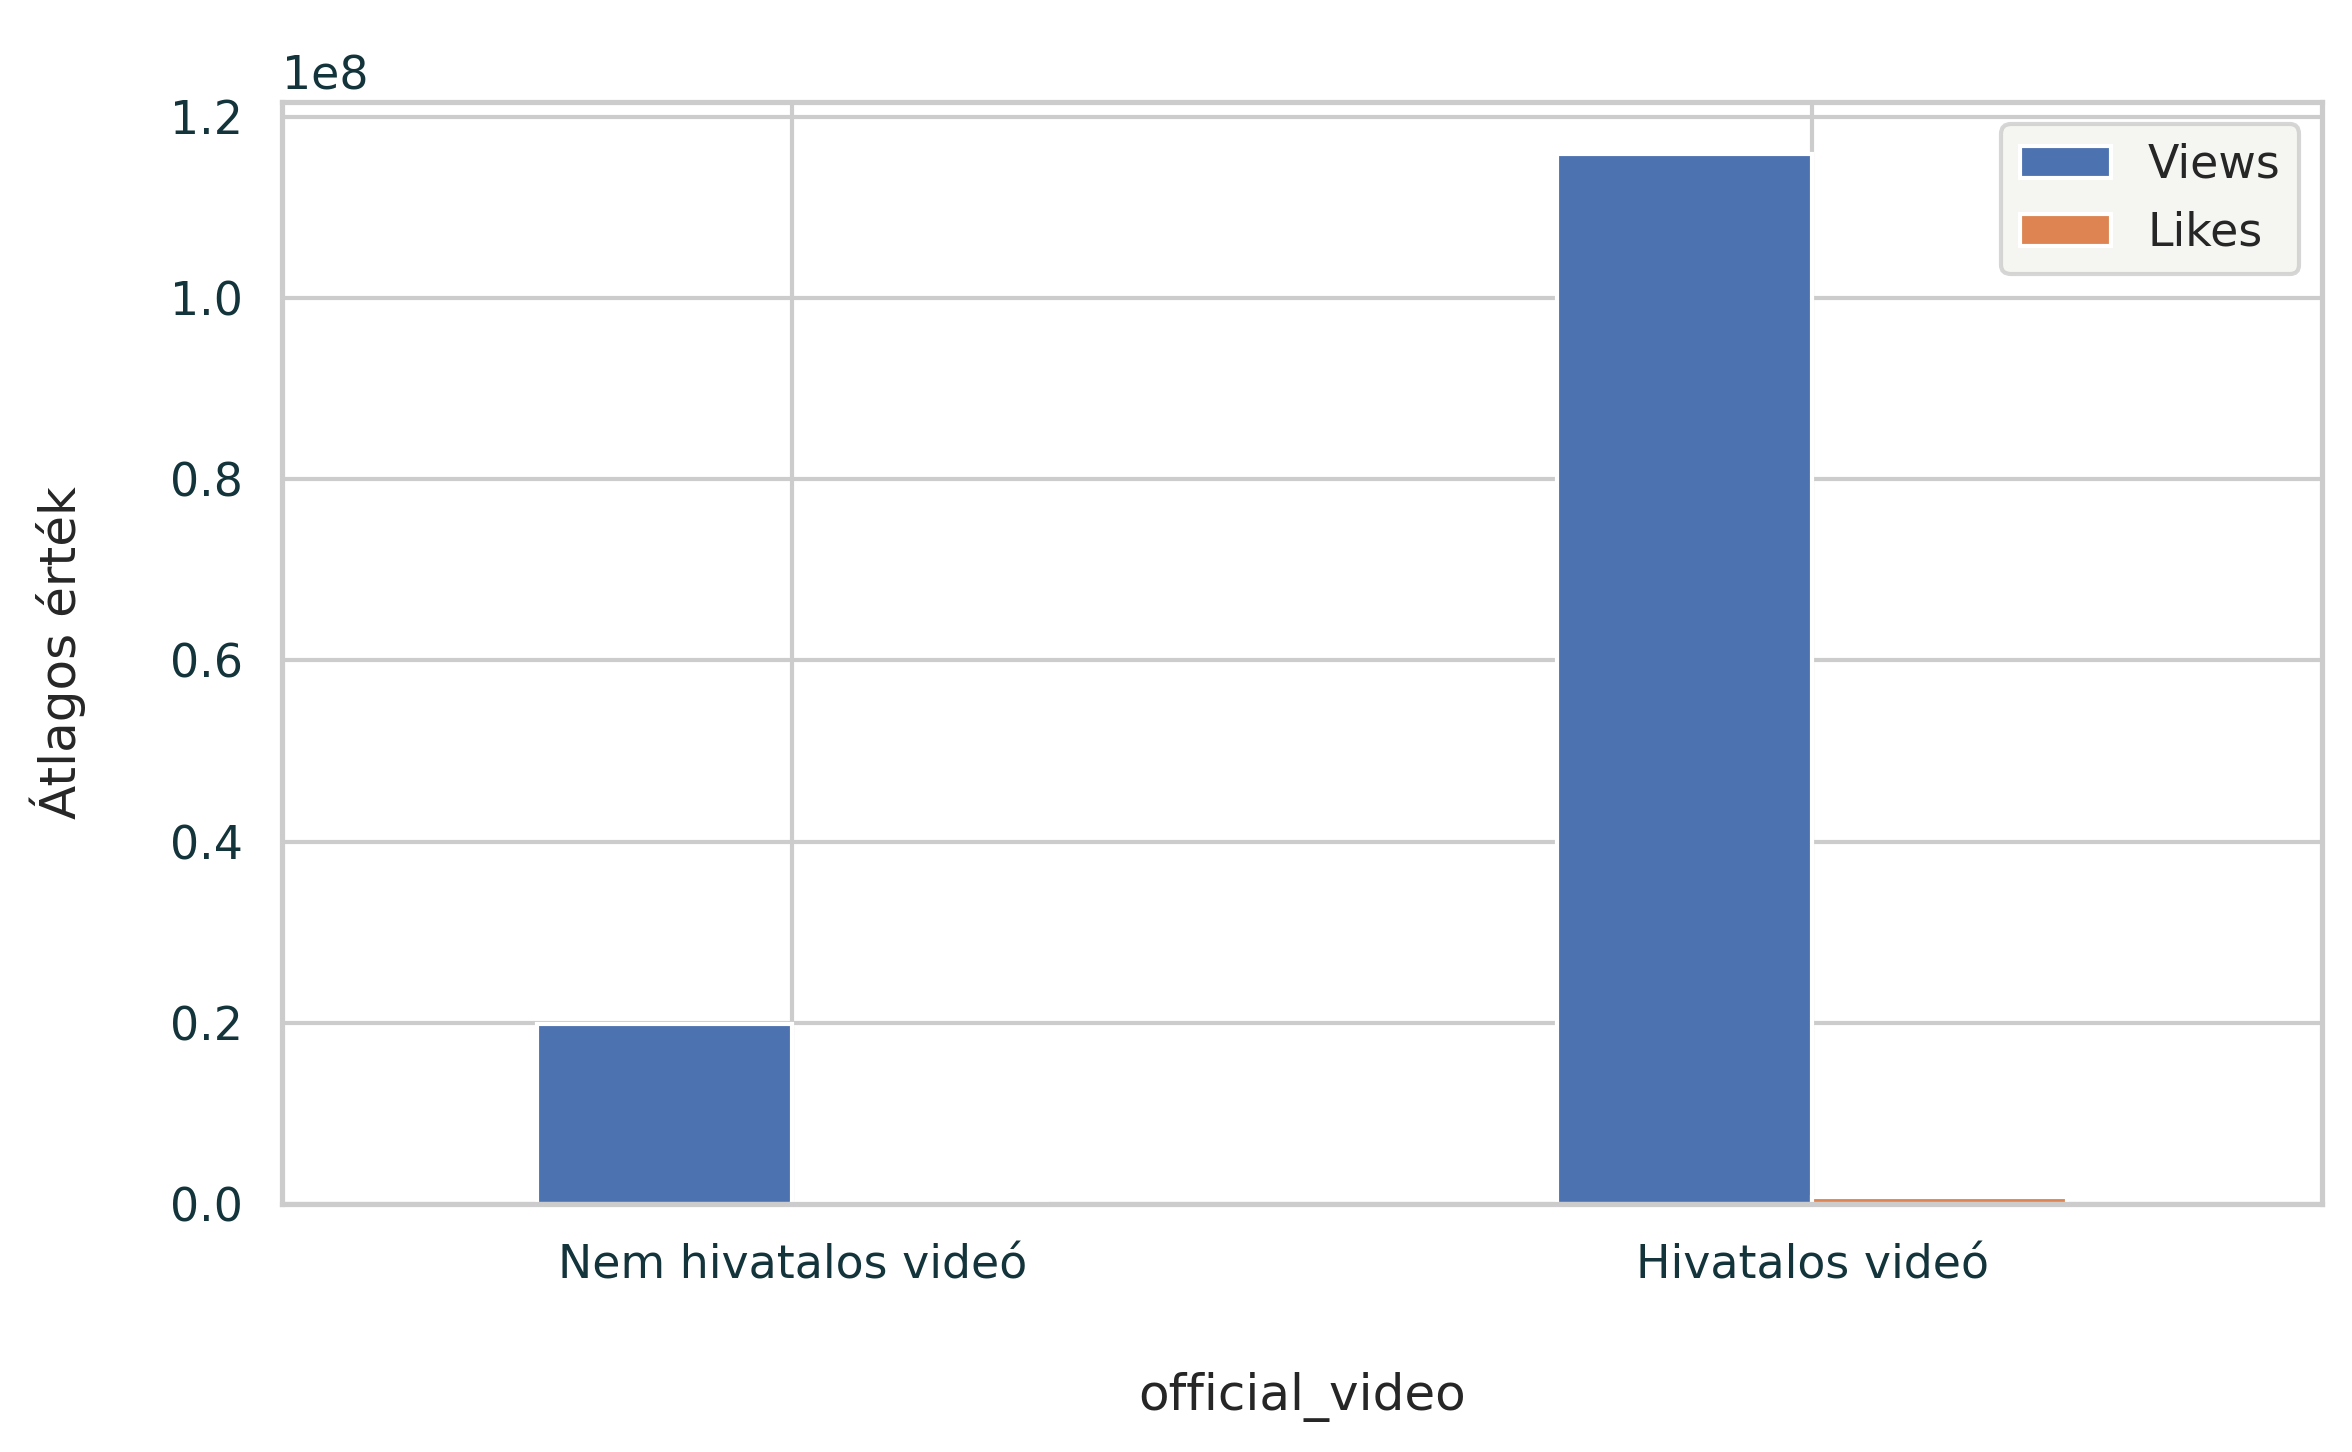

In [15]:
official_comparison = (
    df.groupby('official_video')[['Views', 'Likes', 'Comments', 'Stream']]
    .mean()
    .rename(index={True: 'Hivatalos videó', False: 'Nem hivatalos videó'})
)
print(official_comparison)

official_comparison[['Views', 'Likes']].plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title('Átlagos megtekintés és lájk - hivatalos vs. nem hivatalos videó')
plt.ylabel('Átlagos érték')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Új elemzés: legenergikusabb és leghangosabb dalok

A `Energy` és `Loudness` jellemzők alapján megkeressük a top 10 legenergikusabb számot. Fontos szűrés: kizárjuk a nagyon alacsony hangerejű (`Loudness < -10 dB`) felvételeket (pl. ambient/fehér zaj felvételek), mert azok félrevezetően magas `Energy` értéket kaphatnak anélkül, hogy valóban "pörgős" számok lennének.

In [16]:
top_energy_songs = (
    df[df['Loudness'] > -10]
    .sort_values(['Energy', 'Loudness'], ascending=False)
    [['Artist', 'Track', 'Energy', 'Loudness', 'Tempo']]
    .head(10)
)
print(top_energy_songs)

                        Artist                                    Track  \
10292              The Prodigy                            Voodoo People   
5181                   Scooter                       Maria - Radio Edit   
6062               Lamb of God                                  Redneck   
3591                Mägo de Oz                  El libro de las sombras   
37                   Metallica                               Lux Æterna   
563                   Slipknot                           Wait and Bleed   
10291              The Prodigy                No Good (Start the Dance)   
10294              The Prodigy  Breathe - Mefjus & Camo & Krooked Remix   
7638         Killswitch Engage                               Holy Diver   
11688  Bullet For My Valentine                         Waking the Demon   

       Energy  Loudness    Tempo  
10292   0.998    -5.860  149.002  
5181    0.997    -3.583  142.941  
6062    0.996    -2.100  130.931  
3591    0.996    -2.124  159.054  

## 11. Új elemzés: licenszelt tartalom aránya és stream-kapcsolata

Megnézzük, mekkora arányban vannak licenszelt (`Licensed=True`) tartalmak az adathalmazban, és hogy ez összefügg-e a magasabb stream-számmal.

Licenszelt tartalom aránya (%):
Licensed
True     68.435948
False    31.564052
Name: proportion, dtype: float64

Medián stream-szám licenszeltség szerint:
Licensed
False    40348150.0
True     55692713.0
Name: Stream, dtype: float64


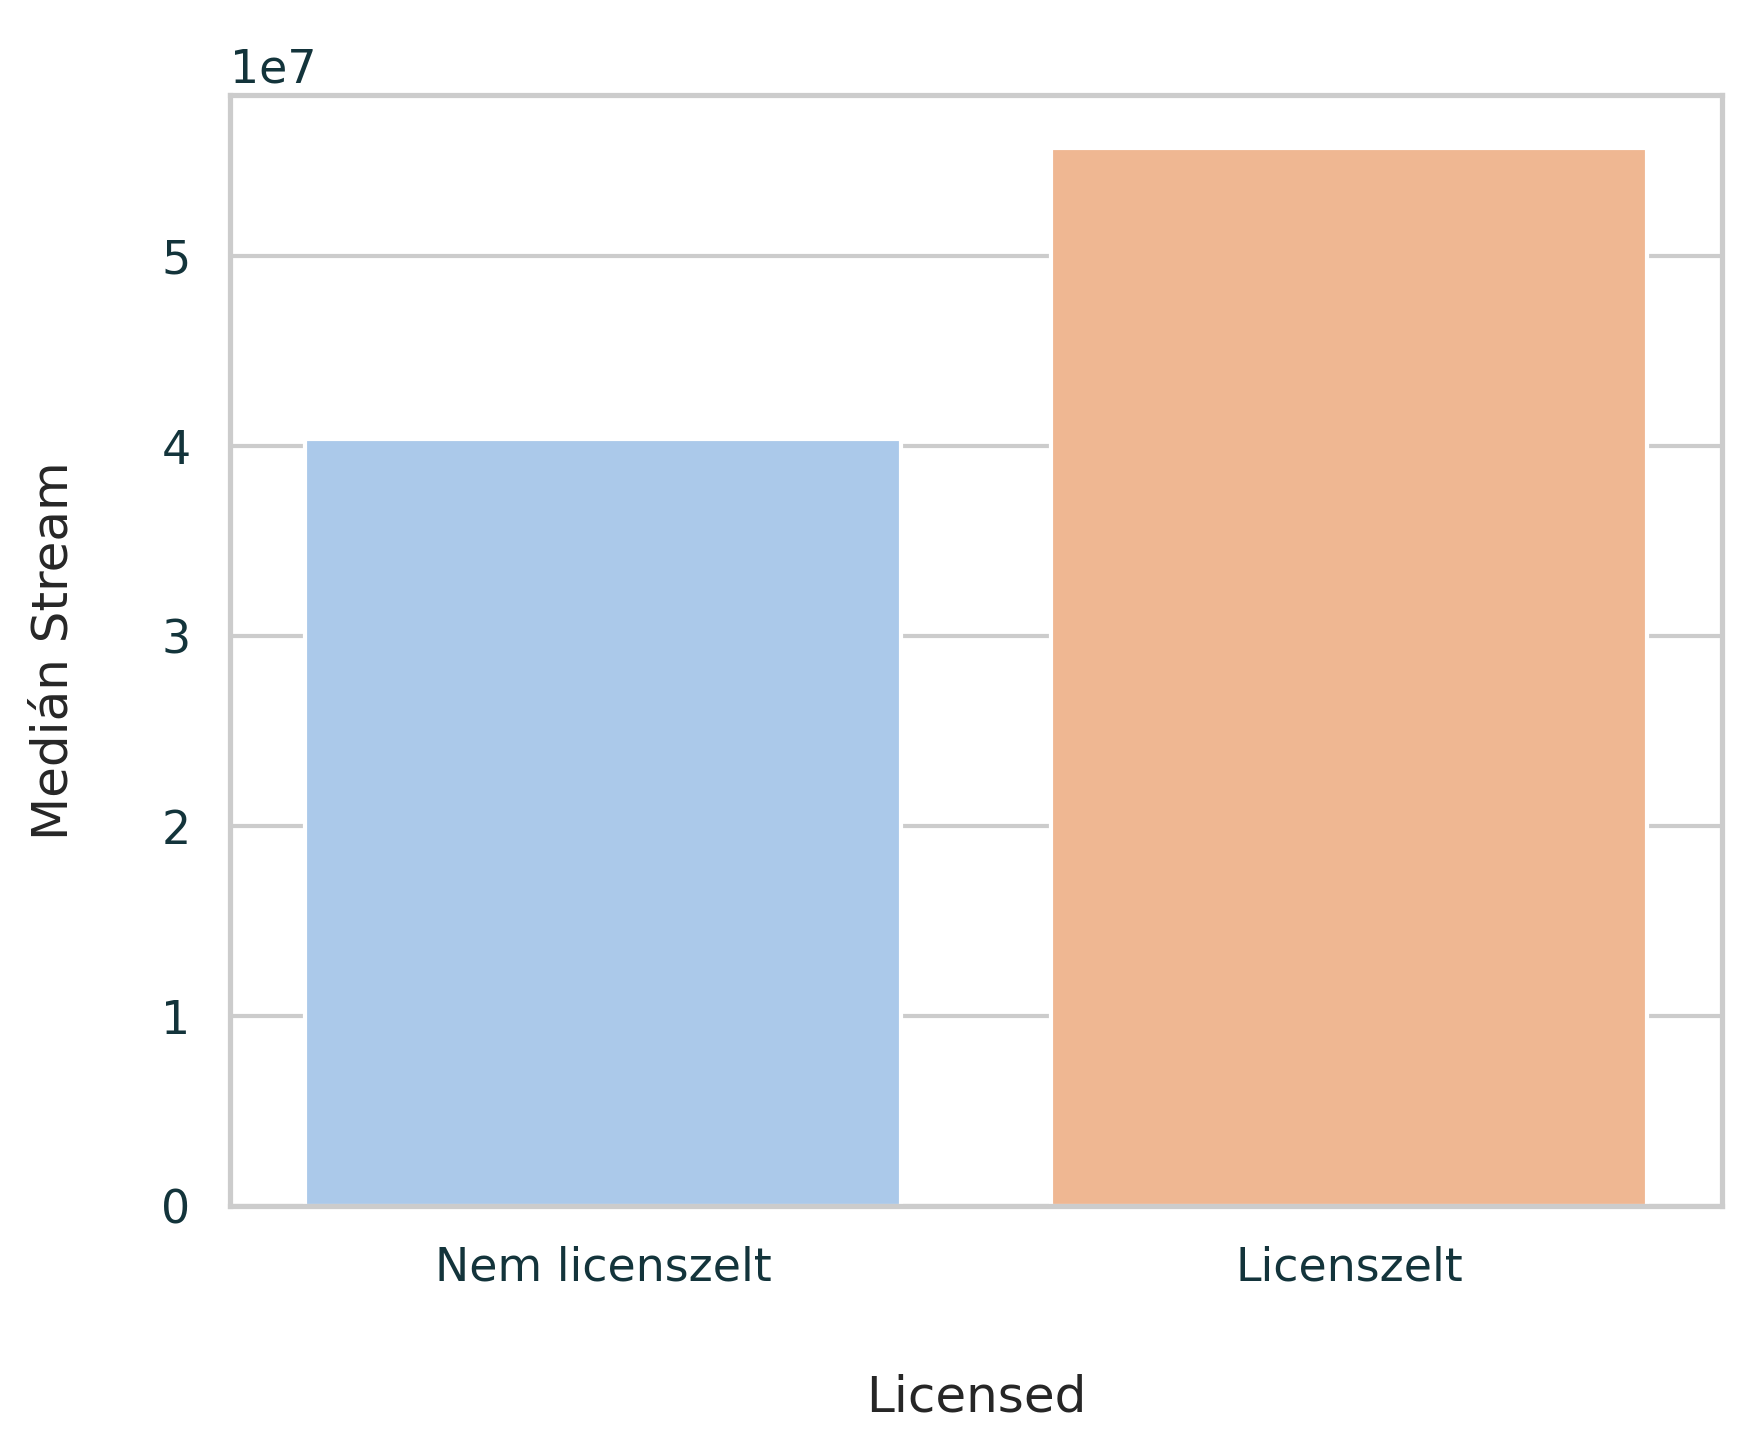

In [17]:
licensed_share = df['Licensed'].value_counts(normalize=True) * 100
print("Licenszelt tartalom aránya (%):")
print(licensed_share)

licensed_stream = df.groupby('Licensed')['Stream'].median()
print("\nMedián stream-szám licenszeltség szerint:")
print(licensed_stream)

plt.figure(figsize=(6, 5))
sns.barplot(x=licensed_stream.index.map({True: 'Licenszelt', False: 'Nem licenszelt'}),
            y=licensed_stream.values, hue=licensed_stream.index, palette='pastel', legend=False)
plt.title('Medián Stream-szám licenszeltség szerint')
plt.ylabel('Medián Stream')
plt.tight_layout()
plt.show()

## 12. Új elemzés: legnépszerűbb hangnem (Key) eloszlás

A `Key` oszlop a dal hangnemét kódolja (0=C, 1=C#/Db, ..., 11=B). Megnézzük, mely hangnemek a leggyakoribbak az adathalmazban.

Key
C        2251
G        2189
C#/Db    2163
D        1967
A        1919
F        1682
B        1617
E        1462
G#/Ab    1443
F#/Gb    1408
A#/Bb    1386
D#/Eb     653
Name: count, dtype: int64


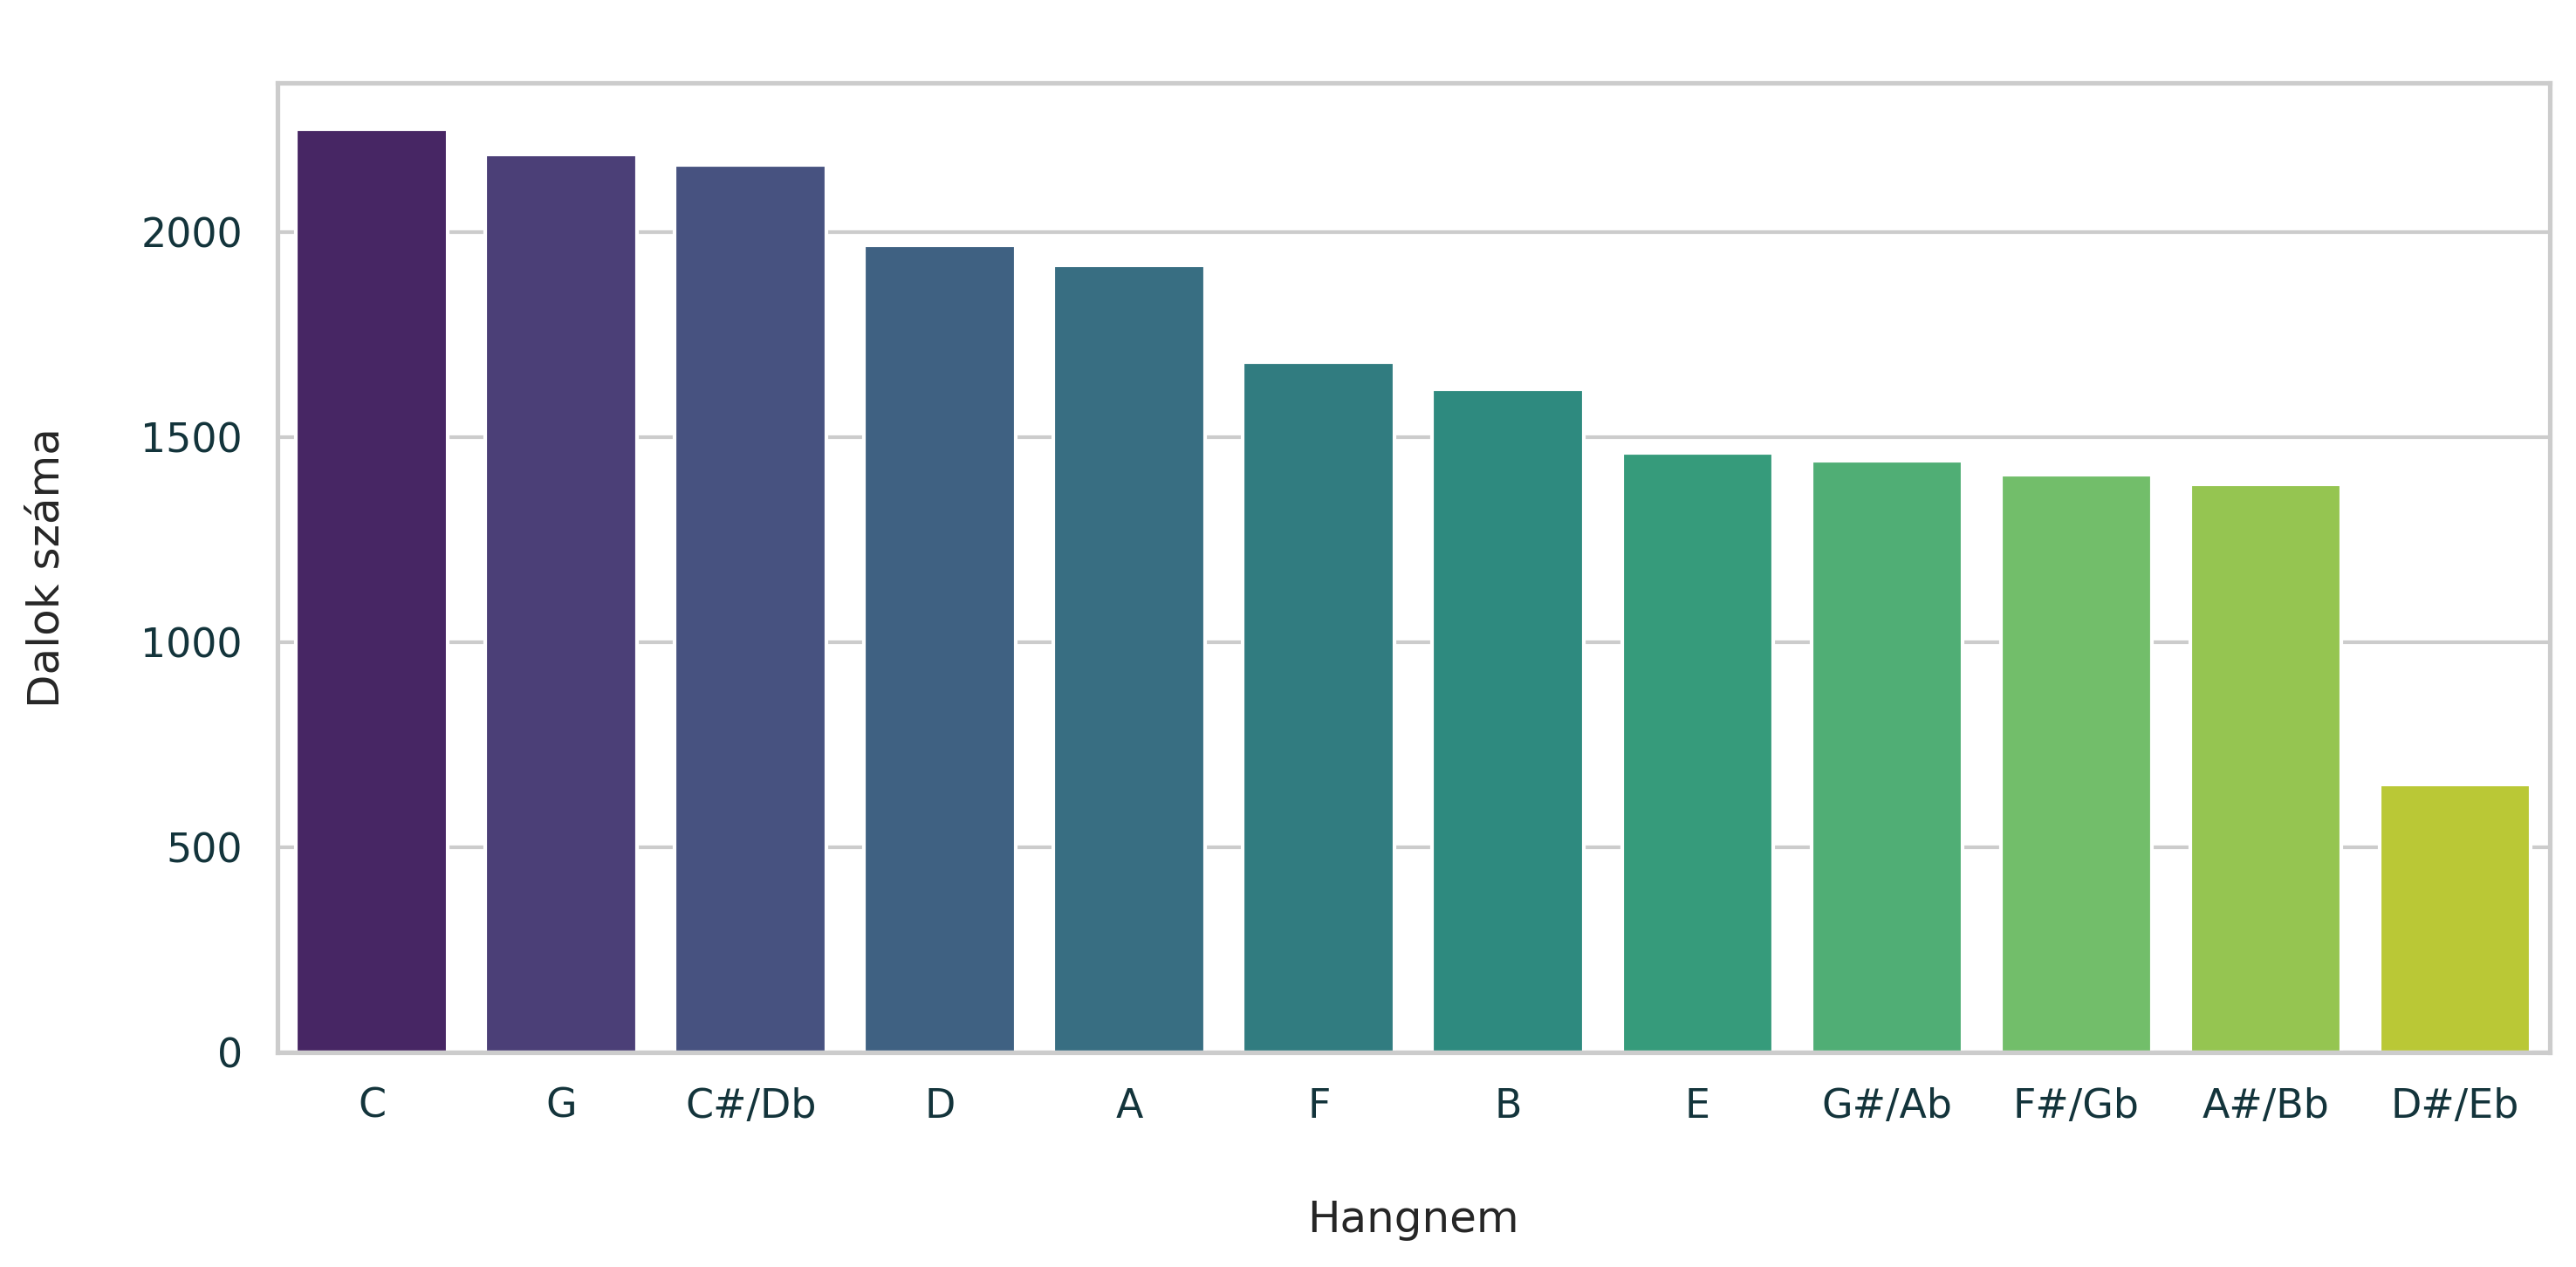

In [18]:
key_names = {0: 'C', 1: 'C#/Db', 2: 'D', 3: 'D#/Eb', 4: 'E', 5: 'F',
             6: 'F#/Gb', 7: 'G', 8: 'G#/Ab', 9: 'A', 10: 'A#/Bb', 11: 'B'}

key_counts = df['Key'].map(key_names).value_counts()
print(key_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=key_counts.index, y=key_counts.values, hue=key_counts.index, palette='viridis', legend=False)
plt.title('Hangnemek (Key) eloszlása az adathalmazban')
plt.xlabel('Hangnem')
plt.ylabel('Dalok száma')
plt.tight_layout()
plt.show()

## Összefoglalás

A notebook bemutatta a teljes adatelemzési munkafolyamatot: adatbetöltéstől a tisztításon és aggregáláson át a vizualizációig. A kiegészítő elemzések (hangulat vs. album típus, hivatalos videók hatása, hangnem-eloszlás, licenszeltség és stream-szám kapcsolata) további betekintést adnak a zenei adatokba, és jól demonstrálják a `pandas`/`NumPy`/`matplotlib`/`seaborn` gyakorlati használatát egy valós, hiányos és vegyes típusú adathalmazon.

**Néhány kiemelt eredmény:**
- A hivatalos videóval rendelkező számok átlagosan **~5x annyi** megtekintést és lájkot kapnak, mint a nem hivatalosak.
- A licenszelt tartalmak medián stream-száma (~55,7M) magasabb, mint a nem licenszelteké (~40,3M).
- A leggyakoribb hangnem a **C**, ezt követi a **G** és a **C#/Db**.
